# Transfer Learning — ResNet18 stem + Random Forest

**The best model in the project: 0.808 per-image accuracy.**

The conventional recipe — fine-tune ResNet18, take `fc = nn.Identity()` as a
512-d embedding, fit a classifier — reaches only **0.629** here, worse than a
plain colour histogram. This notebook diagnoses why and builds the fix.

**The finding:** ImageNet pretraining deliberately builds *colour invariance*
(its augmentation includes colour jitter, because a red bus and a blue bus are
both buses). Here hue **is** the label, so every layer of the hierarchy discards
more of the signal. The standard recipe extracts the most colour-invariant point
in the network.

In [1]:
import csv, warnings
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, cv2, joblib
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
warnings.filterwarnings("ignore"); plt.rcParams["figure.dpi"]=110
SEED=42; CLASSES=[5,6,7,8]
dev=torch.device("mps" if torch.backends.mps.is_available() else
                 "cuda" if torch.cuda.is_available() else "cpu")
rows=list(csv.DictReader(open("preprocessing/splits.csv")))
y=np.array([CLASSES.index(int(r["pH"])) for r in rows])
well=np.array([f'{r["pH"]}_{r["well"]}' for r in rows])
paths=[r["path"] for r in rows]
tf=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),
     transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
print("device:",dev,"|",len(rows),"images")

device: mps | 1963 images


## 1. Diagnosis — which ResNet18 stage carries the pH signal?

Global-average-pool the output of each stage, fit the same Random Forest to each,
score under grouped 5-fold CV.

In [2]:
def cv_acc(X,n=400,leaf=2):
    a=[]
    for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(np.zeros(len(y)),y,groups=well):
        m=RandomForestClassifier(n,min_samples_leaf=leaf,random_state=SEED,n_jobs=-1).fit(X[tr],y[tr])
        a.append(accuracy_score(y[te],m.predict(X[te])))
    return float(np.mean(a)), float(np.std(a))

CACHE="transfer_learning/_stages.npz"
try:
    z=np.load(CACHE); S={k:z[k] for k in z.files}; print("loaded cached stage features")
except FileNotFoundError:
    net=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(dev).eval()
    acc={k:[] for k in ["stem","layer1","layer2","layer3","layer4"]}
    with torch.no_grad():
        for i in range(0,len(paths),64):
            b=torch.stack([tf(Image.open(p).convert("RGB")) for p in paths[i:i+64]]).to(dev)
            x=net.maxpool(net.relu(net.bn1(net.conv1(b))))
            acc["stem"].append(F.adaptive_avg_pool2d(x,1).flatten(1).cpu().numpy())
            for name,layer in [("layer1",net.layer1),("layer2",net.layer2),
                               ("layer3",net.layer3),("layer4",net.layer4)]:
                x=layer(x); acc[name].append(F.adaptive_avg_pool2d(x,1).flatten(1).cpu().numpy())
    S={k:np.vstack(v) for k,v in acc.items()}; np.savez_compressed(CACHE,**S)
probe={k:cv_acc(v) for k,v in S.items()}
for k,(a,s) in probe.items(): print(f"  {k:8s} dim={S[k].shape[1]:4d}   {a:.3f} +/- {s:.3f}")

  stem     dim=  64   0.751 +/- 0.017
  layer1   dim=  64   0.750 +/- 0.028
  layer2   dim= 128   0.713 +/- 0.028
  layer3   dim= 256   0.695 +/- 0.018
  layer4   dim= 512   0.629 +/- 0.021


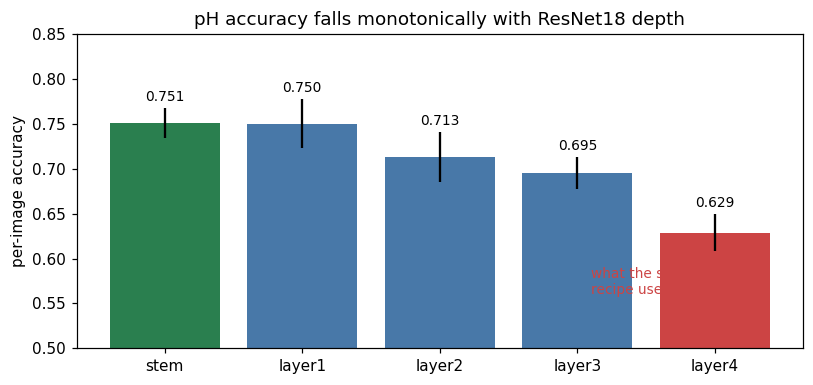

The first convolution beats the final embedding by 12.2 points.


In [3]:
ks=list(probe); vals=[probe[k][0] for k in ks]; errs=[probe[k][1] for k in ks]
fig,ax=plt.subplots(figsize=(7.5,3.6))
cols=["#2a7f4f","#4878a8","#4878a8","#4878a8","#c44"]
ax.bar(ks,vals,yerr=errs,color=cols)
ax.set_ylabel("per-image accuracy"); ax.set_ylim(0.5,0.85)
ax.set_title("pH accuracy falls monotonically with ResNet18 depth")
for i,(v,e) in enumerate(zip(vals,errs)): ax.text(i,v+e+.008,f"{v:.3f}",ha="center",fontsize=9)
ax.annotate("what the standard\nrecipe uses",xy=(4,vals[4]),xytext=(3.1,0.56),
            arrowprops=dict(arrowstyle="->",color="#c44"),color="#c44",fontsize=9)
plt.tight_layout(); plt.show()
print(f"The first convolution beats the final embedding by "
      f"{100*(probe['stem'][0]-probe['layer4'][0]):.1f} points.")

## 2. How much of ResNet18 is actually used?

Only the stem: `conv1 → bn1 → relu → maxpool`. One 7×7 convolution with 64
filters. Everything deeper is discarded, and the weights are frozen — **no neural
network is trained anywhere in this notebook.**

In [4]:
net=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
stem=sum(p.numel() for m in [net.conv1,net.bn1] for p in m.parameters())
total=sum(p.numel() for p in net.parameters())
print(f"ResNet18 total parameters : {total:,}")
print(f"  used (conv1 + bn1)      : {stem:,}  ({100*stem/total:.2f}%)")
print(f"  discarded               : {total-stem:,}")
print(f"  TRAINED by gradient desc: 0  (frozen ImageNet weights)")
print("\nThe only trained component is the Random Forest.")

ResNet18 total parameters : 11,689,512
  used (conv1 + bn1)      : 9,536  (0.08%)
  discarded               : 11,679,976
  TRAINED by gradient desc: 0  (frozen ImageNet weights)

The only trained component is the Random Forest.


## 3. How to pool the stem

The stem output is `(64, 56, 56)`. Global average pooling asks only *what colour
is the gel*. The per-channel **standard deviation** also asks *how uneven is it* —
degradation makes gels patchy, so that heterogeneity is real signal.

In [5]:
CACHE2="transfer_learning/_stem_pool.npz"
try:
    z=np.load(CACHE2); V={k:z[k] for k in z.files}; print("loaded cached pooling variants")
except FileNotFoundError:
    net_d=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(dev).eval()
    acc={"gap":[],"gap_std":[],"p2":[],"p3":[]}
    with torch.no_grad():
        for i in range(0,len(paths),64):
            b=torch.stack([tf(Image.open(p).convert("RGB")) for p in paths[i:i+64]]).to(dev)
            x=net_d.maxpool(net_d.relu(net_d.bn1(net_d.conv1(b)))).cpu()
            gap=F.adaptive_avg_pool2d(x,1).flatten(1)
            acc["gap"].append(gap.numpy())
            acc["gap_std"].append(torch.cat([gap,x.std(dim=(2,3))],1).numpy())
            acc["p2"].append(F.adaptive_avg_pool2d(x,2).flatten(1).numpy())
            acc["p3"].append(F.adaptive_avg_pool2d(x,3).flatten(1).numpy())
    V={k:np.vstack(v) for k,v in acc.items()}; np.savez_compressed(CACHE2,**V)

labels={"gap":"avg pool (64)","gap_std":"avg + std pool (128)",
        "p2":"2x2 spatial (256)","p3":"3x3 spatial (576)"}
pool={labels[k]:cv_acc(V[k]) for k in ["gap","gap_std","p2","p3"]}
for k,(a,s) in pool.items(): print(f"  {k:22s} {a:.3f} +/- {s:.3f}")
print("\nStd pooling wins, and beats richer SPATIAL pooling at a quarter the size:")
print("the variation matters, its location does not.")

  avg pool (64)          0.752 +/- 0.017
  avg + std pool (128)   0.793 +/- 0.017
  2x2 spatial (256)      0.769 +/- 0.029
  3x3 spatial (576)      0.789 +/- 0.034

Std pooling wins, and beats richer SPATIAL pooling at a quarter the size:
the variation matters, its location does not.


## 4. The final model

```
image -> ResNet18 stem (frozen)  -> avg (64) + std (64)  = 128-d
      -> 8x8x8 HSV histogram                             = 512-d
      -> concat                                          = 640-d
      -> RandomForest(400 trees)                         -> pH
```

In [6]:
def histogram_features(ps):
    out=[]
    for p in ps:
        img=cv2.resize(cv2.imread(p),(128,128))
        hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
        h=cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
        out.append(cv2.normalize(h,h).flatten())
    return np.array(out,np.float32)

H=np.load("supervised/_features.npz")["X"] if __import__("os").path.exists("supervised/_features.npz")   else histogram_features(paths)
X=np.hstack([V["gap_std"],H])
print("final feature matrix:",X.shape)

steps={"ResNet18 layer4 embedding (standard recipe)":cv_acc(S["layer4"]),
       "HSV histogram alone":cv_acc(H),
       "stem, avg pool":cv_acc(V["gap"]),
       "stem, avg+std pool":cv_acc(V["gap_std"]),
       "stem (avg+std) + histogram  <- FINAL":cv_acc(X)}
for k,(a,s) in steps.items(): print(f"  {k:44s} {a:.3f} +/- {s:.3f}")

final feature matrix: (1963, 640)


  ResNet18 layer4 embedding (standard recipe)  0.629 +/- 0.021
  HSV histogram alone                          0.755 +/- 0.017
  stem, avg pool                               0.752 +/- 0.017
  stem, avg+std pool                           0.793 +/- 0.017
  stem (avg+std) + histogram  <- FINAL         0.808 +/- 0.021


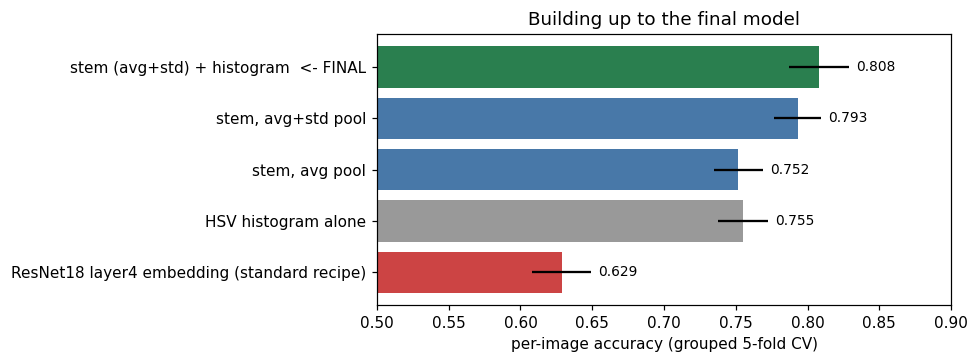

In [7]:
fig,ax=plt.subplots(figsize=(9,3.4))
ks=list(steps); vs=[steps[k][0] for k in ks]; es=[steps[k][1] for k in ks]
ax.barh(ks,vs,xerr=es,color=["#c44","#999","#4878a8","#4878a8","#2a7f4f"])
ax.set_xlim(0.5,0.9); ax.set_xlabel("per-image accuracy (grouped 5-fold CV)")
ax.set_title("Building up to the final model")
for i,(v,e) in enumerate(zip(vs,es)): ax.text(v+e+.005,i,f"{v:.3f}",va="center",fontsize=9)
plt.tight_layout(); plt.show()

## 5. Final evaluation

In [8]:
accs=[];f1s=[];bins=[];CM=np.zeros((4,4),int); last=None
for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(np.zeros(len(y)),y,groups=well):
    m=RandomForestClassifier(400,min_samples_leaf=2,random_state=SEED,n_jobs=-1).fit(X[tr],y[tr])
    p=m.predict(X[te])
    accs.append(accuracy_score(y[te],p)); f1s.append(f1_score(y[te],p,average="macro"))
    bins.append(accuracy_score(y[te]>=2,p>=2)); CM+=confusion_matrix(y[te],p,labels=range(4))
    last=(y[te],p)
print(f"PER-IMAGE, grouped 5-fold CV over 192 wells ({len(y)} images)\n")
print(f"  accuracy          {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
print(f"  macro F1          {np.mean(f1s):.3f}")
print(f"  acid vs alkaline  {np.mean(bins):.3f} +/- {np.std(bins):.3f}")
print()
print(classification_report(*last,target_names=[f"pH{c}" for c in CLASSES]))

PER-IMAGE, grouped 5-fold CV over 192 wells (1963 images)

  accuracy          0.808 +/- 0.021
  macro F1          0.806
  acid vs alkaline  0.955 +/- 0.010

              precision    recall  f1-score   support

         pH5       0.92      0.87      0.90       125
         pH6       0.84      0.83      0.83        87
         pH7       0.77      0.81      0.79        86
         pH8       0.80      0.82      0.81       101

    accuracy                           0.84       399
   macro avg       0.83      0.83      0.83       399
weighted avg       0.84      0.84      0.84       399



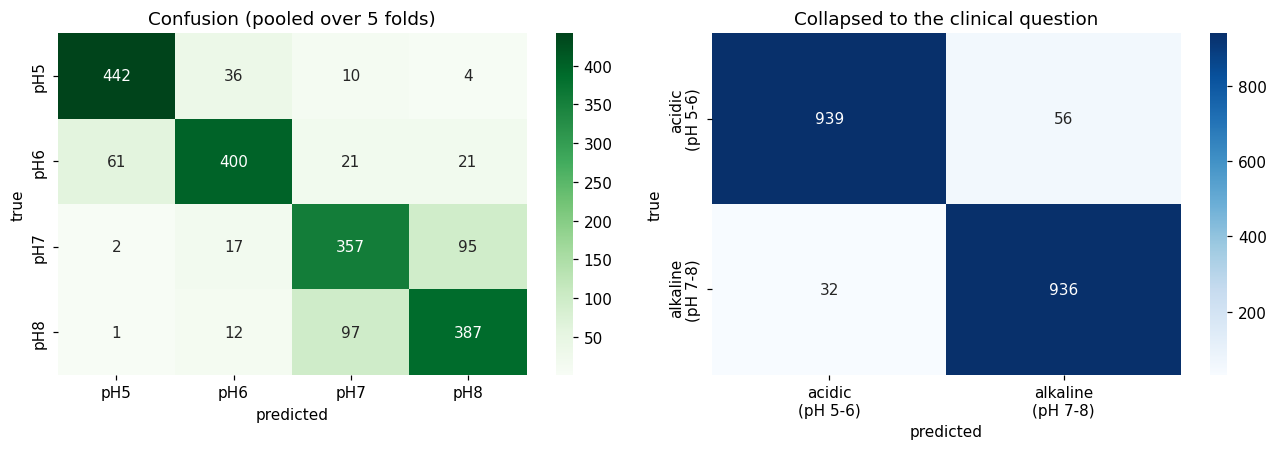

377 errors of 1963; only 88 (4.5%) cross
the acid/alkaline boundary. Healthy skin is pH 4-6, chronic wounds pH 7-8,
so the clinically important call is far better than the 4-way figure suggests.


In [9]:
fig,ax=plt.subplots(1,2,figsize=(12,4.2))
sns.heatmap(CM,annot=True,fmt="d",cmap="Greens",ax=ax[0],
            xticklabels=[f"pH{c}" for c in CLASSES],yticklabels=[f"pH{c}" for c in CLASSES])
ax[0].set_title("Confusion (pooled over 5 folds)"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
B=np.array([[CM[:2,:2].sum(),CM[:2,2:].sum()],[CM[2:,:2].sum(),CM[2:,2:].sum()]])
sns.heatmap(B,annot=True,fmt="d",cmap="Blues",ax=ax[1],
            xticklabels=["acidic\n(pH 5-6)","alkaline\n(pH 7-8)"],
            yticklabels=["acidic\n(pH 5-6)","alkaline\n(pH 7-8)"])
ax[1].set_title("Collapsed to the clinical question"); ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
plt.tight_layout(); plt.show()
cross=CM[:2,2:].sum()+CM[2:,:2].sum()
print(f"{CM.sum()-np.trace(CM)} errors of {CM.sum()}; only {cross} ({100*cross/CM.sum():.1f}%) cross")
print("the acid/alkaline boundary. Healthy skin is pH 4-6, chronic wounds pH 7-8,")
print("so the clinically important call is far better than the 4-way figure suggests.")

## 6. Fit the final model on all data

In [10]:
final=RandomForestClassifier(400,min_samples_leaf=2,random_state=SEED,n_jobs=-1).fit(X,y)
joblib.dump(final,"transfer_learning/resnet_rf_model.pkl")
print("saved -> transfer_learning/resnet_rf_model.pkl")
imp=final.feature_importances_
print(f"\nfeature importance: stem avg {imp[:64].sum():.3f} | stem std {imp[64:128].sum():.3f} "
      f"| histogram {imp[128:].sum():.3f}")
print("All three blocks contribute; none dominates.")

saved -> transfer_learning/resnet_rf_model.pkl

feature importance: stem avg 0.277 | stem std 0.353 | histogram 0.370
All three blocks contribute; none dominates.


---
## Summary

| Model | per-image accuracy |
|---|---|
| ResNet18 layer4 embedding (standard recipe) | 0.629 |
| HSV histogram alone | 0.755 |
| stem, avg pool | 0.752 |
| stem, avg+std pool | 0.793 |
| **stem (avg+std) + histogram** | **0.808** |

Only **0.08%** of ResNet18's weights are used, and none are trained. The lesson
is that ImageNet's deep features are a liability when colour is the label.